## 1 Create the training and validation datasets
### 1.1 Load the data


In [1]:
import pickle

# Validate algorithm against training project data with known m-heights
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-n_k_m_P', 'rb') as f:
    training_data = pickle.load(f)
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-mHeights', 'rb') as f:
    expected_heights = pickle.load(f)

#Create a 70/20/10 random training/validation/test split
from sklearn.model_selection import train_test_split
train_data, temp_data, train_heights, temp_heights = train_test_split(
    training_data, expected_heights, test_size=0.3, random_state=42)
val_data, test_data, val_heights, test_heights = train_test_split(
    temp_data, temp_heights, test_size=1/3, random_state=42)


### 1.2 Pre-process the data
n=9
k is in [4,5,6]
m is in [2,..,n-k]

So we have 9 combinations for n,k,m
1 n = 9 , k = 4 , m = 2
2. n = 9 , k = 4 , m = 3
3. n = 9 , k = 4 , m = 4
4. n = 9 , k = 4 , m = 5
5. n = 9 , k = 5 , m = 2
6. n = 9 , k = 5 , m = 3
7. n = 9 , k = 5 , m = 4
8. n = 9 , k = 6 , m = 2
9. n = 9 , k = 6 , m = 3

P is a 2-dimensional numpy array of k rows and n-k columns

We need to normalize and convert this data into a single tensor of 37 dimensions (3 for k values + 4 for m values + 30 for P)

In [2]:
#We need to convert the training data into a format suitable for our algorithm. Assuming the training data is in the form of a list of tuples (n, k, m, P), we can extract the features and labels as follows:
#Normalize the values in P (from -100 to 100) to be between 0 and 1
#Because n is always 9, we can ignore it as a feature
import numpy as np
import tensorflow as tf

#K can be 4, 5, or 6 for our case
def one_hot_encode_k(k):
    if k == 4:
        return [1, 0, 0]
    elif k == 5:
        return [0, 1, 0]
    elif k == 6:
        return [0, 0, 1]
    else:
        raise ValueError("Invalid value for k: {}".format(k))
#m can be 2-5 for our case    
def one_hot_encode_m(m):
    if m == 2:
        return [1, 0, 0, 0]
    elif m == 3:
        return [0, 1, 0, 0]
    elif m == 4:
        return [0, 0, 1, 0]
    elif m == 5:
        return [0, 0, 0, 1]
    else:
        raise ValueError("Invalid value for m: {}".format(m))

def preprocess_P(P, k, n=9):
    P = (P + 100) / 200.0
    # Pad to max size: 6 rows x 5 cols = 30
    P_pad = np.zeros((6, 5))
    P_pad[:k, :n-k] = P
    return P_pad.flatten()  # always 30 values   

def preprocess_labels(heights):
    # Log transform the heights to make them more suitable for regression
    # In case of log(0) or log of negative numbers, we can add a small constant to the heights before taking the log
    heights = np.array(heights)
    heights = heights + 1e-6  # Add a small constant to avoid log(0)
    heights = np.log(heights)  
    return heights

def preprocess_features(data):
    features = []
    for n, k, m, P in data:
        feat = np.concatenate([one_hot_encode_k(k), one_hot_encode_m(m), preprocess_P(P, k, n)])
        features.append(feat)
    return np.array(features, dtype=np.float32)  # shape: (N, 37)
 
X_train, y_train = preprocess_features(train_data), preprocess_labels(train_heights)
X_val, y_val = preprocess_features(val_data), preprocess_labels(val_heights)
X_test, y_test = preprocess_features(test_data), preprocess_labels(test_heights)

#Print shapes to verify
print("Training features shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Validation features shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)
print("Test features shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

#Print sample features and labels to verify
print("Sample training features (first 5):", X_train[:5])
print("Sample training labels (first 5):", y_train[:5])

# Build tf.data pipelines: cache keeps data in GPU memory, prefetch overlaps
# CPU batch prep with GPU training to keep the GPU fully fed
BATCH_SIZE = 4096
ds_train = (tf.data.Dataset.from_tensor_slices((X_train, y_train.astype('float32')))
            .cache()
            .shuffle(len(X_train), seed=42)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))
ds_val = (tf.data.Dataset.from_tensor_slices((X_val, y_val.astype('float32')))
          .cache()
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))
ds_test = (tf.data.Dataset.from_tensor_slices((X_test, y_test.astype('float32')))
           .cache()
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))
print(f"\nDatasets built with BATCH_SIZE={BATCH_SIZE}: "
      f"{len(ds_train)} train batches, {len(ds_val)} val batches, {len(ds_test)} test batches per epoch")


2026-03-12 19:13:39.739710: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 19:13:39.962871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-12 19:13:40.052240: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-12 19:13:40.080852: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-12 19:13:40.215054: I tensorflow/core/platform/cpu_feature_guar

Training features shape: (67566, 37)
Training labels shape: (67566,)
Validation features shape: (19305, 37)
Validation labels shape: (19305,)
Test features shape: (9653, 37)
Test labels shape: (9653,)
Sample training features (first 5): [[0.    0.    1.    0.    1.    0.    0.    0.28  0.39  0.515 0.    0.
  0.275 0.61  0.41  0.    0.    0.66  0.295 0.305 0.    0.    0.535 0.59
  0.3   0.    0.    0.34  0.53  0.605 0.    0.    0.295 0.425 0.425 0.
  0.   ]
 [1.    0.    0.    1.    0.    0.    0.    0.705 0.85  0.295 0.5   0.825
  0.335 0.485 0.61  0.435 0.475 0.42  0.36  0.595 0.5   0.39  0.495 0.365
  0.435 0.715 0.33  0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.    0.    1.    1.    0.    0.    0.    0.3   0.955 0.12  0.    0.
  0.65  0.445 0.675 0.    0.    0.28  0.665 0.145 0.    0.    0.615 0.84
  0.325 0.    0.    0.22  0.99  0.435 0.    0.    0.865 0.825 0.415 0.
  0.   ]
 [1.    0.    0.    0.    0.    1.    0.    0.9   0.845 0.255 0.895 0.91
  0.92  0.315 

I0000 00:00:1773342823.661968    5649 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773342824.013331    5649 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773342824.013377    5649 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773342824.017505    5649 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773342824.017570    5649 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0


Datasets built with BATCH_SIZE=4096: 17 train batches, 5 val batches, 3 test batches per epoch


## 2 Create the models
 * The first input is an integer n.
 * The second input is an integer k.
 *  The third input is an integer m.
 * The fourth input is a k ⇥(n k) matrix Pk⇥(nk) (as a 2-dimensional
numpy array), which forms the last n k columns of a systematic k ⇥n
generator matrix G.

* The output is a continuous value m-height

### 2.1 Create a basic baseline model

In [3]:
#Create DNN model:
 # * The first input is an integer n - we will ignore this since n is always 9.
#  * The second input is an integer k.
#  *  The third input is an integer m.
#  * The fourth input is a k ⇥(n k) matrix Pk⇥(nk) (as a 2-dimensional
# numpy array), which forms the last n k columns of a systematic k ⇥n
# generator matrix G.

# * The output is a continuous positive value m-height
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_basic_model():
    # Define inputs - single flat vector: 3 (k one-hot) + 4 (m one-hot) + 30 (P padded) = 37
    inputs = keras.Input(shape=(37,), name='input')

    # Add hidden layers
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)

    # Output layer for log(m-height) prediction - linear activation for regression
    # Don't use ReLU here because we want to allow the model to predict any real value 
    # (log(m-height) can be negative), and we will exponentiate the output later to get m-height
    output = layers.Dense(1, name='m_height_output')(x)

    # Create the model
    model = keras.Model(inputs=inputs, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    return model



### 2.2 Create a Deeper Neural Network with skip layers and batch normalization

In [4]:
def create_deeper_model():
    inputs = keras.Input(shape=(37,), name='input')
    
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    # Residual block 1 (256 -> 256)
    skip1 = x
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256)(x)  # no activation before the add
    x = layers.Add()([x, skip1])
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Residual block 2 (128 -> 128)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    skip2 = x  # save AFTER projecting to 128
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128)(x)  # no activation before the add
    x = layers.Add()([x, skip2])
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    
    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

### 2.3 Create a model with regularization

In [5]:
def create_regularized_model():
    # Define inputs - single flat vector: 3 (k one-hot) + 4 (m one-hot) + 30 (P padded) = 37
    inputs = keras.Input(shape=(37,), name='input')

    # Add hidden layers with L2 regularization
    x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(inputs)
    x = layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)

    # Output layer for log(m-height) prediction - linear activation for regression
    output = layers.Dense(1, name='m_height_output')(x)

    # Create the model
    model = keras.Model(inputs=inputs, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    return model

### 2.4 Create a CNN

In [6]:
def create_convolutional_model():
    # Full input: 3 (k one-hot) + 4 (m one-hot) + 30 (P padded) = 37
    inputs = keras.Input(shape=(37,), name='input')

    # Split: k/m metadata vs P matrix
    km_features = layers.Lambda(lambda x: x[:, :7])(inputs)   # first 7: k + m one-hots
    p_features = layers.Lambda(lambda x: x[:, 7:])(inputs)     # last 30: flattened P

    # Reshape P to (6, 5, 1) for Conv2D
    p_reshaped = layers.Reshape((6, 5, 1))(p_features)

    # Conv layers with small kernels (input is only 6x5)
    x = layers.Conv2D(32, (2, 2), activation='relu', padding='same')(p_reshaped)
    x = layers.Conv2D(64, (2, 2), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Concatenate conv features with k/m metadata
    x = layers.Concatenate()([km_features, x])

    # Fully connected layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)

    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

### 2.5 Create a Mixture of Experts

In [7]:
def create_moe_models():
    """
    Mixture of Experts: train 9 separate models, one per (k, m) combination.
    Each expert only sees the P features (30-dim) since k and m are fixed for that expert.
    Returns a dict mapping (k, m) -> compiled model.
    """
    models = {}
    configs = [
        (4, 2), (4, 3), (4, 4), (4, 5),
        (5, 2), (5, 3), (5, 4),
        (6, 2), (6, 3),
    ]
    for k_val, m_val in configs:
        inputs = keras.Input(shape=(30,), name=f'P_input_k{k_val}_m{m_val}')
        x = layers.Dense(128, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dense(32, activation='relu')(x)
        output = layers.Dense(1, name='m_height_output')(x)
        model = keras.Model(inputs=inputs, outputs=output)
        model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
        models[(k_val, m_val)] = model
    return models

def train_moe_models(models, X_train, y_train, X_val, y_val, epochs=50, batch_size=4096, callbacks=None):
    """Train each expert on its subset of data. Returns dict of histories."""
    histories = {}
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        # Filter training data for this (k, m)
        train_mask = (X_train[:, k_idx] == 1) & (X_train[:, 3 + m_idx] == 1)
        val_mask = (X_val[:, k_idx] == 1) & (X_val[:, 3 + m_idx] == 1)
        # Extract only the P features (columns 7:37)
        X_tr = X_train[train_mask, 7:].astype('float32')
        y_tr = y_train[train_mask].astype('float32')
        X_v = X_val[val_mask, 7:].astype('float32')
        y_v = y_val[val_mask].astype('float32')
        # Scale batch size to ~1/8 of expert dataset so we get ~8 batches/epoch
        # (avoids the 1-batch-per-epoch problem when global batch_size >> expert dataset)
        expert_bs = max(32, min(batch_size, len(X_tr) // 8))
        print(f"\nTraining expert for k={k_val}, m={m_val} | train={len(X_tr)}, val={len(X_v)}, bs={expert_bs}")
        # Build per-expert tf.data datasets
        ds_tr = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                 .cache().shuffle(len(X_tr), seed=42)
                 .batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        ds_v = (tf.data.Dataset.from_tensor_slices((X_v, y_v))
                .cache().batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        history = model.fit(ds_tr, validation_data=ds_v,
                            epochs=epochs, verbose=1,
                            callbacks=callbacks)
        histories[(k_val, m_val)] = history
    return histories

def predict_moe(models, X_data):
    """Use the appropriate expert for each sample based on its k/m one-hot encoding."""
    predictions = np.zeros(len(X_data))
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
        if mask.sum() > 0:
            predictions[mask] = model.predict(X_data[mask, 7:], verbose=0).flatten()
    return predictions


### 2.5b Create a CNN Mixture of Experts

In [8]:
_P_INDICES = {
    k: [row * 5 + col for row in range(k) for col in range(9 - k)]
    for k in [4, 5, 6]
}

def create_cnn_moe_models():
    """
    CNN Mixture of Experts: 9 separate CNN models, one per (k, m) combination.
    Each expert uses the native (unpadded) P matrix for its k value:
      k=4 -> 4x5 = 20-dim P  (columns 0..4)
      k=5 -> 5x4 = 20-dim P  (columns 0..3)
      k=6 -> 6x3 = 18-dim P  (columns 0..2)
    """
    models = {}
    configs = [
        (4, 2), (4, 3), (4, 4), (4, 5),
        (5, 2), (5, 3), (5, 4),
        (6, 2), (6, 3),
    ]
    for k_val, m_val in configs:
        n_rows, n_cols = k_val, 9 - k_val
        p_dim = n_rows * n_cols
        inputs = keras.Input(shape=(p_dim,), name=f'P_input_k{k_val}_m{m_val}')
        x = layers.Reshape((n_rows, n_cols, 1))(inputs)
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(32, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, name='m_height_output')(x)
        model = keras.Model(inputs=inputs, outputs=output)
        model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
        models[(k_val, m_val)] = model
    return models


def train_cnn_moe_models(models, X_train, y_train, X_val, y_val,
                         epochs=50, batch_size=256, callbacks=None):
    """Train each CNN expert on its own (k, m) subset using native P features."""
    histories = {}
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        train_mask = (X_train[:, k_idx] == 1) & (X_train[:, 3 + m_idx] == 1)
        val_mask   = (X_val[:,   k_idx] == 1) & (X_val[:,   3 + m_idx] == 1)
        col_idx = [7 + i for i in _P_INDICES[k_val]]
        X_tr = X_train[train_mask][:, col_idx].astype('float32')
        y_tr = y_train[train_mask].astype('float32')
        X_v  = X_val[val_mask][:, col_idx].astype('float32')
        y_v  = y_val[val_mask].astype('float32')
        expert_bs = max(32, min(batch_size, len(X_tr) // 8))
        print(f"\nCNN expert k={k_val}, m={m_val} | train={len(X_tr)}, val={len(X_v)}, "
              f"input_dim={len(col_idx)} ({k_val}x{9-k_val}), bs={expert_bs}")
        ds_tr = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                 .cache().shuffle(len(X_tr), seed=42).batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        ds_v  = (tf.data.Dataset.from_tensor_slices((X_v, y_v))
                 .cache().batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        history = model.fit(ds_tr, validation_data=ds_v, epochs=epochs, verbose=1, callbacks=callbacks)
        histories[(k_val, m_val)] = history
    return histories


def predict_cnn_moe(models, X_data):
    """Run each CNN expert on its subset and assemble into a single prediction array."""
    predictions = np.zeros(len(X_data))
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
        if mask.sum() > 0:
            col_idx = [7 + i for i in _P_INDICES[k_val]]
            predictions[mask] = model.predict(X_data[mask][:, col_idx], verbose=0).flatten()
    return predictions

## 2.6 Create a NN with custom loss that matches our grading 

In [9]:
# Note: The grading cost is (log2(y) - log2(y_hat))^2.
# Since our targets are ln(y), this equals (ln(y) - ln(y_hat))^2 / ln(2)^2.
# That is just MSE / ln(2)^2, so MSE is already proportional to the grading metric.
# No custom loss needed — standard MSE on log-transformed targets is optimal.
#
# If you still want to see it explicitly:
def log2_mse_loss(y_true, y_pred):
    """Grading-equivalent loss: (log2(y) - log2(y_hat))^2, where inputs are in ln-space."""
    ln2 = tf.cast(tf.math.log(2.0), dtype=y_true.dtype)
    return tf.reduce_mean(tf.square((y_true - y_pred) / ln2))

def create_custom_loss_model():
    inputs = keras.Input(shape=(37,), name='input')
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
    return model

### 2.7 CNN with custom log₂ MSE loss
Combines the convolutional architecture (spatial P-matrix processing) with the grading-aligned loss function.

In [10]:
def create_cnn_custom_loss_model():
    """CNN architecture compiled with the grading-aligned log2 MSE loss."""
    inputs = keras.Input(shape=(37,), name='input')
    km_features = layers.Lambda(lambda x: x[:, :7])(inputs)
    p_features  = layers.Lambda(lambda x: x[:, 7:])(inputs)
    p_reshaped = layers.Reshape((6, 5, 1))(p_features)
    x = layers.Conv2D(32, (2, 2), activation='relu', padding='same')(p_reshaped)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (2, 2), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Concatenate()([km_features, x])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
    return model

## 3 Train and compare all models
### 3.1 Basic model

In [11]:
EPOCHS = 500
results = {}  # store (model, history) for each model type

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
)

# --- 1. Basic Model ---
print("=" * 60)
print("Training: Basic Model")
print("=" * 60)
basic_model = create_basic_model()
basic_history = basic_model.fit(ds_train, validation_data=ds_val,
                                epochs=EPOCHS, verbose=1,
                                callbacks=[early_stop],
)
results['Basic'] = (basic_model, basic_history)


Training: Basic Model
Epoch 1/500


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

11/17 [==================>...........] - ETA: 0s - loss: 39.6101 - mae: 5.8738 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


17/17 [==============================] - 2s 13ms/step - loss: 37.3764 - mae: 5.6755 - val_loss: 28.8670 - val_mae: 4.8826
Epoch 2/500
17/17 [==============================] - 0s 6ms/step - loss: 17.9569 - mae: 3.5275 - val_loss: 5.5031 - val_mae: 1.7980
Epoch 3/500
17/17 [==============================] - 0s 7ms/step - loss: 5.8780 - mae: 2.0204 - val_loss: 4.5010 - val_mae: 1.6738
Epoch 4/500
17/17 [==============================] - 0s 8ms/step - loss: 4.2515 - mae: 1.5903 - val_loss: 3.6027 - val_mae: 1.5144
Epoch 5/500
17/17 [==============================] - 0s 7ms/step - loss: 3.2337 - mae: 1.4078 - val_loss: 2.6550 - val_mae: 1.2528
Epoch 6/500
17/17 [==============================] - 0s 6ms/step - loss: 2.3295 - mae: 1.1692 - val_loss: 1.9009 - val_mae: 1.0549
Epoch 7/500
17/17 [==============================] - 0s 6ms/step - loss: 1.7071 - mae: 0.9982 - val_loss: 1.4718 - val_mae: 0.9332
Epoch 8/500
17/17 [==============================] - 0s 6ms/step - loss: 1.3876 - mae: 0.90

### 3.2 Deeper Model

In [12]:
# --- 2. Deeper Model (with residual connections + BatchNorm) ---
print("=" * 60)
print("Training: Deeper Model")
print("=" * 60)
deeper_model = create_deeper_model()
deeper_history = deeper_model.fit(ds_train, validation_data=ds_val,
                                  epochs=EPOCHS, verbose=1,
                                  callbacks=[keras.callbacks.EarlyStopping(
                                      monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['Deeper'] = (deeper_model, deeper_history)


Training: Deeper Model
Epoch 1/500


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 1/17 [>.............................] - ETA: 47s - loss: 47.7192 - mae: 6.5271

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

17/17 [==============================] - 3s 26ms/step - loss: 19.5570 - mae: 3.7567 - val_loss: 31.0206 - val_mae: 5.2056
Epoch 2/500
17/17 [==============================] - 0s 16ms/step - loss: 1.5913 - mae: 0.9657 - val_loss: 22.1575 - val_mae: 4.3077
Epoch 3/500
17/17 [==============================] - 0s 16ms/step - loss: 0.9032 - mae: 0.7110 - val_loss: 19.6335 - val_mae: 4.0611
Epoch 4/500
17/17 [==============================] - 0s 16ms/step - loss: 0.7504 - mae: 0.6310 - val_loss: 17.4824 - val_mae: 3.8006
Epoch 5/500
17/17 [==============================] - 0s 17ms/step - loss: 0.6925 - mae: 0.6010 - val_loss: 15.9299 - val_mae: 3.6045
Epoch 6/500
17/17 [==============================] - 0s 17ms/step - loss: 0.6471 - mae: 0.5733 - val_loss: 15.0305 - val_mae: 3.4886
Epoch 7/500
17/17 [==============================] - 0s 17ms/step - loss: 0.6190 - mae: 0.5601 - val_loss: 13.9912 - val_mae: 3.3496
Epoch 8/500
17/17 [==============================] - 0s 17ms/step - loss: 0.5994

### 3.3 Regularized Model

In [13]:
print("=" * 60)
print("Training: Regularized Model")
print("=" * 60)
regularized_model = create_regularized_model()
regularized_history = regularized_model.fit(ds_train, validation_data=ds_val,
                                            epochs=EPOCHS, verbose=1,
                                            callbacks=[keras.callbacks.EarlyStopping(
                                                monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['Regularized'] = (regularized_model, regularized_history)


Training: Regularized Model
Epoch 1/500


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

17/17 [==============================] - 1s 11ms/step - loss: 29.4049 - mae: 4.8359 - val_loss: 12.7258 - val_mae: 2.8428


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 2/500
17/17 [==============================] - 0s 8ms/step - loss: 7.5916 - mae: 2.1952 - val_loss: 5.7251 - val_mae: 1.9797
Epoch 3/500
17/17 [==============================] - 0s 8ms/step - loss: 4.8728 - mae: 1.6862 - val_loss: 4.1433 - val_mae: 1.5161
Epoch 4/500
17/17 [==============================] - 0s 8ms/step - loss: 3.8200 - mae: 1.4936 - val_loss: 3.2806 - val_mae: 1.3558
Epoch 5/500
17/17 [==============================] - 0s 8ms/step - loss: 2.9967 - mae: 1.2851 - val_loss: 2.5405 - val_mae: 1.1804
Epoch 6/500
17/17 [==============================] - 0s 8ms/step - loss: 2.2702 - mae: 1.1041 - val_loss: 1.8932 - val_mae: 1.0054
Epoch 7/500
17/17 [==============================] - 0s 7ms/step - loss: 1.6931 - mae: 0.9432 - val_loss: 1.4602 - val_mae: 0.8740
Epoch 8/500
17/17 [==============================] - 0s 8ms/step - loss: 1.3710 - mae: 0.8409 - val_loss: 1.2648 - val_mae: 0.7995
Epoch 9/500
17/17 [==============================] - 0s 7ms/step - loss: 1.2249 - m

### 3.4 Convolutional Model

In [14]:
print("=" * 60)
print("Training: Convolutional Model")
print("=" * 60)
conv_model = create_convolutional_model()
conv_history = conv_model.fit(ds_train, validation_data=ds_val,
                              epochs=EPOCHS, verbose=1,
                              callbacks=[keras.callbacks.EarlyStopping(
                                  monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['Convolutional'] = (conv_model, conv_history)


Training: Convolutional Model
Epoch 1/500


W0000 00:00:1773343020.981982    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.014934    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.025741    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.026517    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.026745    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.027039    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.027355    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.041981    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.050737    5872 gp

 8/17 [=============>................] - ETA: 0s - loss: 42.1203 - mae: 6.1008

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1773343021.680973    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.681137    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.681277    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.687490    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.687823    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.687964    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343021.688093    5869 gpu_timer.cc:114] Skipping

17/17 [==============================] - 2s 27ms/step - loss: 40.5657 - mae: 5.9692 - val_loss: 35.8803 - val_mae: 5.5653
Epoch 2/500


...

17/17 [==============================] - 0s 10ms/step - loss: 0.8072 - mae: 0.6657 - val_loss: 0.7830 - val_mae: 0.6559
Epoch 18/500
 7/17 [===========>..................] - ETA: 0s - loss: 0.8067 - mae: 0.6651

W0000 00:00:1773343025.527446    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.527717    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.527875    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.528099    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.528246    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.528463    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.528607    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.528764    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.529275    5872 gp

17/17 [==============================] - 0s 10ms/step - loss: 0.7978 - mae: 0.6607 - val_loss: 0.7752 - val_mae: 0.6513
Epoch 19/500
 8/17 [=============>................] - ETA: 0s - loss: 0.7969 - mae: 0.6590

W0000 00:00:1773343025.736653    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.736916    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.737079    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.737323    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.737471    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.737709    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.738096    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.738265    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343025.738850    5872 gp

17/17 [==============================] - 0s 9ms/step - loss: 0.7910 - mae: 0.6565 - val_loss: 0.7675 - val_mae: 0.6465
Epoch 20/500
17/17 [==============================] - 0s 9ms/step - loss: 0.7818 - mae: 0.6512 - val_loss: 0.7595 - val_mae: 0.6420
Epoch 21/500
17/17 [==============================] - 0s 10ms/step - loss: 0.7720 - mae: 0.6459 - val_loss: 0.7510 - val_mae: 0.6364
Epoch 22/500
17/17 [==============================] - 0s 9ms/step - loss: 0.7600 - mae: 0.6395 - val_loss: 0.7377 - val_mae: 0.6289
Epoch 23/500
17/17 [==============================] - 0s 9ms/step - loss: 0.7459 - mae: 0.6318 - val_loss: 0.7231 - val_mae: 0.6196
Epoch 24/500
17/17 [==============================] - 0s 9ms/step - loss: 0.7312 - mae: 0.6231 - val_loss: 0.7088 - val_mae: 0.6111
Epoch 25/500
17/17 [==============================] - 0s 9ms/step - loss: 0.7164 - mae: 0.6145 - val_loss: 0.6954 - val_mae: 0.6027
Epoch 26/500
17/17 [==============================] - 0s 8ms/step - loss: 0.7029 - mae: 

### 3.5 Mixture of Experts

In [15]:
# --- 3.5. Mixture of Experts (9 separate models, one per (k, m)) ---
print("=" * 60)
print("Training: Mixture of Experts (9 experts)")
print("=" * 60)
moe_models = create_moe_models()
moe_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
)
moe_histories = train_moe_models(moe_models, X_train, y_train, X_val, y_val,
                                 epochs=EPOCHS, batch_size=BATCH_SIZE,
                                 callbacks=[moe_early_stop],
)


Training: Mixture of Experts (9 experts)

Training expert for k=4, m=2 | train=7770, val=2276, bs=971
Epoch 1/500


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1/9 [==>...........................] - ETA: 9s - loss: 22.6038 - mae: 4.5052

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

9/9 [==============================] - 1s 24ms/step - loss: 17.5132 - mae: 3.9514 - val_loss: 15.2372 - val_mae: 3.7478
Epoch 2/500
9/9 [==============================] - 0s 10ms/step - loss: 10.1889 - mae: 2.9776 - val_loss: 14.4338 - val_mae: 3.6433
Epoch 3/500
9/9 [==============================] - 0s 9ms/step - loss: 6.5368 - mae: 2.3121 - val_loss: 13.7845 - val_mae: 3.5538
Epoch 4/500
9/9 [==============================] - 0s 10ms/step - loss: 4.3258 - mae: 1.8077 - val_loss: 13.1371 - val_mae: 3.4633
Epoch 5/500
9/9 [==============================] - 0s 12ms/step - loss: 2.9631 - mae: 1.4273 - val_loss: 12.3454 - val_mae: 3.3444
Epoch 6/500
9/9 [==============================] - 0s 11ms/step - loss: 2.1630 - mae: 1.1696 - val_loss: 11.6758 - val_mae: 3.2392
Epoch 7/500
9/9 [==============================] - 0s 11ms/step - loss: 1.7202 - mae: 1.0170 - val_loss: 11.1063 - val_mae: 3.1439
Epoch 8/500
9/9 [==============================] - 0s 11ms/step - loss: 1.4677 - mae: 0.9321 -

...

9/9 [==============================] - 1s 21ms/step - loss: 13.4072 - mae: 3.4607 - val_loss: 27.4248 - val_mae: 5.1046
Epoch 2/500
9/9 [==============================] - 0s 9ms/step - loss: 7.4025 - mae: 2.4558 - val_loss: 25.6684 - val_mae: 4.9278
Epoch 3/500
9/9 [==============================] - 0s 10ms/step - loss: 4.2664 - mae: 1.7144 - val_loss: 23.4680 - val_mae: 4.6934
Epoch 4/500
9/9 [==============================] - 0s 10ms/step - loss: 2.7069 - mae: 1.2866 - val_loss: 21.3640 - val_mae: 4.4567
Epoch 5/500
9/9 [==============================] - 0s 10ms/step - loss: 1.9732 - mae: 1.0776 - val_loss: 19.5331 - val_mae: 4.2399
Epoch 6/500
9/9 [==============================] - 0s 12ms/step - loss: 1.5720 - mae: 0.9592 - val_loss: 17.9843 - val_mae: 4.0482
Epoch 7/500
9/9 [==============================] - 0s 11ms/step - loss: 1.3406 - mae: 0.8818 - val_loss: 16.5351 - val_mae: 3.8604
Epoch 8/500
9/9 [==============================] - 0s 11ms/step - loss: 1.1787 - mae: 0.8241 - 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

7/9 [======================>.......] - ETA: 0s - loss: 76.2461 - mae: 8.5385

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

9/9 [==============================] - 1s 22ms/step - loss: 74.9699 - mae: 8.4663 - val_loss: 78.1479 - val_mae: 8.7295
Epoch 2/500
9/9 [==============================] - 0s 11ms/step - loss: 58.2601 - mae: 7.4614 - val_loss: 74.5532 - val_mae: 8.5206
Epoch 3/500
9/9 [==============================] - 0s 10ms/step - loss: 46.7732 - mae: 6.6421 - val_loss: 70.8416 - val_mae: 8.3001
Epoch 4/500
9/9 [==============================] - 0s 9ms/step - loss: 37.1525 - mae: 5.8491 - val_loss: 66.6000 - val_mae: 8.0398
Epoch 5/500
9/9 [==============================] - 0s 11ms/step - loss: 28.9696 - mae: 5.0713 - val_loss: 62.0372 - val_mae: 7.7502
Epoch 6/500
9/9 [==============================] - 0s 12ms/step - loss: 22.0048 - mae: 4.3156 - val_loss: 57.0884 - val_mae: 7.4244
Epoch 7/500
9/9 [==============================] - 0s 10ms/step - loss: 16.3590 - mae: 3.6149 - val_loss: 52.6873 - val_mae: 7.1229
Epoch 8/500
9/9 [==============================] - 0s 11ms/step - loss: 12.0084 - mae: 2.

### 3.5B Mixture of CNN  Experts

In [16]:
# --- 3.5b. CNN Mixture of Experts (9 separate CNN models, one per (k, m)) ---
print("=" * 60)
print("Training: CNN Mixture of Experts (9 experts)")
print("=" * 60)
cnn_moe_models = create_cnn_moe_models()
cnn_moe_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)
cnn_moe_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
)
cnn_moe_histories = train_cnn_moe_models(cnn_moe_models, X_train, y_train, X_val, y_val,
                                          epochs=EPOCHS, batch_size=256,
                                          callbacks=[cnn_moe_lr_cb, cnn_moe_early_stop],)


Training: CNN Mixture of Experts (9 experts)

CNN expert k=4, m=2 | train=7770, val=2276, input_dim=20 (4x5), bs=256
Epoch 1/500


W0000 00:00:1773343253.891827    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343253.892001    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343253.892089    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343253.892165    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343253.892249    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343253.892566    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343253.892685    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343253.892864    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343253.893012    5869 gp

 5/31 [===>..........................] - ETA: 0s - loss: 35.0243 - mae: 3.9728  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1773343254.742022    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343254.742170    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343254.742267    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343254.742359    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343254.742494    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343254.742614    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343254.742708    5872 gpu_timer.cc:114] Skipping

27/31 [=========================>....] - ETA: 0s - loss: 20.8318 - mae: 2.8366

...

 1/31 [..............................] - ETA: 35s - loss: 164.2300 - mae: 8.7712

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

31/31 [==============================] - 2s 12ms/step - loss: 100.5290 - mae: 6.4665 - val_loss: 118.0661 - val_mae: 7.4102 - lr: 0.0010
Epoch 2/500
 1/31 [..............................] - ETA: 0s - loss: 47.4916 - mae: 4.1132

W0000 00:00:1773343485.004588    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343485.004743    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343485.004851    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343485.004906    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343485.004957    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343485.005107    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343485.005212    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343485.005312    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343485.005467    5875 gp

31/31 [==============================] - 0s 8ms/step - loss: 29.1434 - mae: 3.0858 - val_loss: 74.1211 - val_mae: 5.7846 - lr: 0.0010
Epoch 3/500
31/31 [==============================] - 0s 7ms/step - loss: 14.7557 - mae: 2.1176 - val_loss: 38.3934 - val_mae: 4.0250 - lr: 0.0010
Epoch 4/500
31/31 [==============================] - 0s 7ms/step - loss: 12.1322 - mae: 1.9243 - val_loss: 16.2763 - val_mae: 2.4163 - lr: 0.0010
Epoch 5/500
31/31 [==============================] - 0s 7ms/step - loss: 11.1512 - mae: 1.8434 - val_loss: 6.0410 - val_mae: 1.3269 - lr: 0.0010
Epoch 6/500
31/31 [==============================] - 0s 7ms/step - loss: 10.0965 - mae: 1.7497 - val_loss: 6.9217 - val_mae: 1.4744 - lr: 0.0010
Epoch 7/500
31/31 [==============================] - 0s 7ms/step - loss: 9.7338 - mae: 1.7198 - val_loss: 16.6349 - val_mae: 2.4826 - lr: 0.0010
Epoch 8/500
31/31 [==============================] - 0s 7ms/step - loss: 9.5632 - mae: 1.6969 - val_loss: 29.7157 - val_mae: 3.4837 - lr: 0

### 3.6 Custom Loss Model

In [17]:
# --- 5. Custom Loss Model ---
print("=" * 60)
print("Training: Custom Loss Model (log2 MSE)")
print("=" * 60)
custom_model = create_custom_loss_model()
custom_history = custom_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                  epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
                                  callbacks=[keras.callbacks.EarlyStopping(
                                      monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['Custom Loss'] = (custom_model, custom_history)


Training: Custom Loss Model (log2 MSE)
Epoch 1/500


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

11/17 [==================>...........] - ETA: 0s - loss: 78.7425 - mae: 5.7158 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


17/17 [==============================] - 1s 13ms/step - loss: 70.3378 - mae: 5.3245 - val_loss: 38.2939 - val_mae: 3.6956
Epoch 2/500
17/17 [==============================] - 0s 6ms/step - loss: 18.5836 - mae: 2.3877 - val_loss: 12.8928 - val_mae: 2.1332
Epoch 3/500
17/17 [==============================] - 0s 6ms/step - loss: 9.1847 - mae: 1.6564 - val_loss: 7.2697 - val_mae: 1.4081
Epoch 4/500
17/17 [==============================] - 0s 6ms/step - loss: 6.2958 - mae: 1.3496 - val_loss: 5.0830 - val_mae: 1.2048
Epoch 5/500
17/17 [==============================] - 0s 7ms/step - loss: 4.6023 - mae: 1.1371 - val_loss: 3.8042 - val_mae: 1.0420
Epoch 6/500
17/17 [==============================] - 0s 6ms/step - loss: 3.4795 - mae: 0.9929 - val_loss: 2.9765 - val_mae: 0.9249
Epoch 7/500
17/17 [==============================] - 0s 6ms/step - loss: 2.8527 - mae: 0.9043 - val_loss: 2.5926 - val_mae: 0.8657
Epoch 8/500
17/17 [==============================] - 0s 6ms/step - loss: 2.5522 - mae: 0.8

### 3.7 CNN with Custom Loss Model

In [18]:
# --- CNN + Custom Loss Model ---
print("=" * 60)
print("Training: CNN + Custom Loss Model")
print("=" * 60)
cnn_custom_model = create_cnn_custom_loss_model()
cnn_custom_history = cnn_custom_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                          epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
                                          callbacks=[keras.callbacks.EarlyStopping(
                                              monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)],
)
results['CNN + Custom Loss'] = (cnn_custom_model, cnn_custom_history)


Training: CNN + Custom Loss Model
Epoch 1/500


W0000 00:00:1773343562.855520    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343562.857020    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343562.857570    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343562.857870    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343562.858279    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343562.858903    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343562.859324    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343562.859801    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343562.860163    5866 gp

 8/17 [=============>................] - ETA: 0s - loss: 31.8058 - mae: 3.0624 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


17/17 [==============================] - ETA: 0s - loss: 18.4560 - mae: 2.1234

W0000 00:00:1773343563.738249    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.738501    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.738790    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.738976    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.739244    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.739522    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.739877    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.740130    5869 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.740490    5869 gp

17/17 [==============================] - 3s 25ms/step - loss: 18.4560 - mae: 2.1234 - val_loss: 74.0877 - val_mae: 5.5746
Epoch 2/500
14/17 [=======================>......] - ETA: 0s - loss: 2.2499 - mae: 0.7429

W0000 00:00:1773343563.959259    5865 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.959632    5865 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.960011    5865 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.960247    5865 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.960545    5865 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.960899    5865 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.961185    5865 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.961492    5865 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343563.961775    5865 gp

17/17 [==============================] - 0s 11ms/step - loss: 2.1578 - mae: 0.7297 - val_loss: 71.4657 - val_mae: 5.4826
Epoch 3/500
17/17 [==============================] - 0s 11ms/step - loss: 1.4838 - mae: 0.6134 - val_loss: 68.9174 - val_mae: 5.3666
Epoch 4/500
17/17 [==============================] - 0s 11ms/step - loss: 1.3313 - mae: 0.5700 - val_loss: 66.5069 - val_mae: 5.2506
Epoch 5/500
17/17 [==============================] - 0s 11ms/step - loss: 1.2858 - mae: 0.5583 - val_loss: 63.7659 - val_mae: 5.1198
Epoch 6/500
17/17 [==============================] - 0s 12ms/step - loss: 1.2309 - mae: 0.5448 - val_loss: 61.6964 - val_mae: 5.0191
Epoch 7/500
17/17 [==============================] - 0s 12ms/step - loss: 1.2103 - mae: 0.5412 - val_loss: 59.0151 - val_mae: 4.8886
Epoch 8/500
17/17 [==============================] - 0s 12ms/step - loss: 1.1853 - mae: 0.5337 - val_loss: 56.6713 - val_mae: 4.7719
Epoch 9/500
17/17 [==============================] - 0s 13ms/step - loss: 1.1645 

## 4 Compare all models

W0000 00:00:1773343584.032267    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343584.032391    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343584.032446    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343584.032498    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343584.032549    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343584.032595    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343584.032657    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343584.032768    5866 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343584.032923    5866 gp


  PER-GROUP AVERAGE COST  (lower = better)
Model                   k=4,m=2  k=4,m=3  k=4,m=4  k=4,m=5  k=5,m=2  k=5,m=3  k=5,m=4  k=6,m=2  k=6,m=3
-------------------------------------------------------------------------------------------------------
Basic                    0.2933   0.3556   0.6752   2.5114   0.4315   0.7670   2.8181   0.5700   2.3985
Deeper                   0.2387   0.2833   0.6520   2.4790   0.4334   0.6157   2.6120   0.5152   2.4183
Regularized              0.3830   0.4086   0.8549   2.3771   0.4462   0.7845   2.5563   0.5688   2.3856
Convolutional            0.3384   0.3645   0.8645   2.4422   0.3615   0.8248   2.5881   0.5432   2.3107
Custom Loss              0.3057   0.3635   0.7493   2.4698   0.3874   0.7225   2.7918   0.5588   2.3525
CNN + Custom Loss        0.2753   0.3007   0.6343   2.2269   0.3879   0.6540   2.4425   0.5093   2.2177
MoE                      0.6175   0.8108   1.0028   2.4829   0.6161   1.3248   3.1633   1.2154   2.8557
CNN MoE             

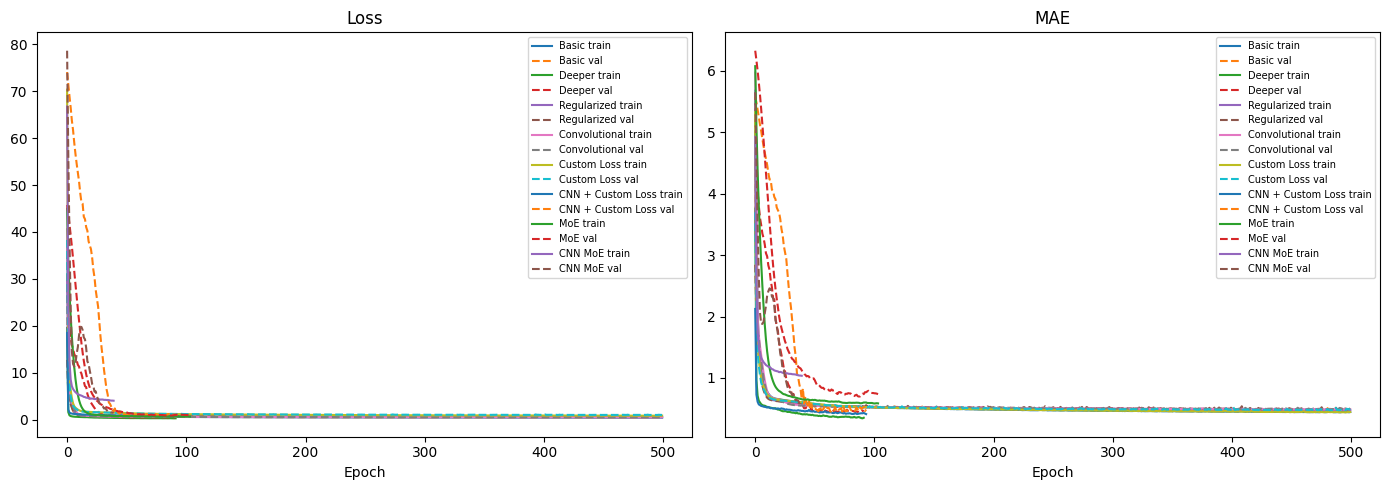

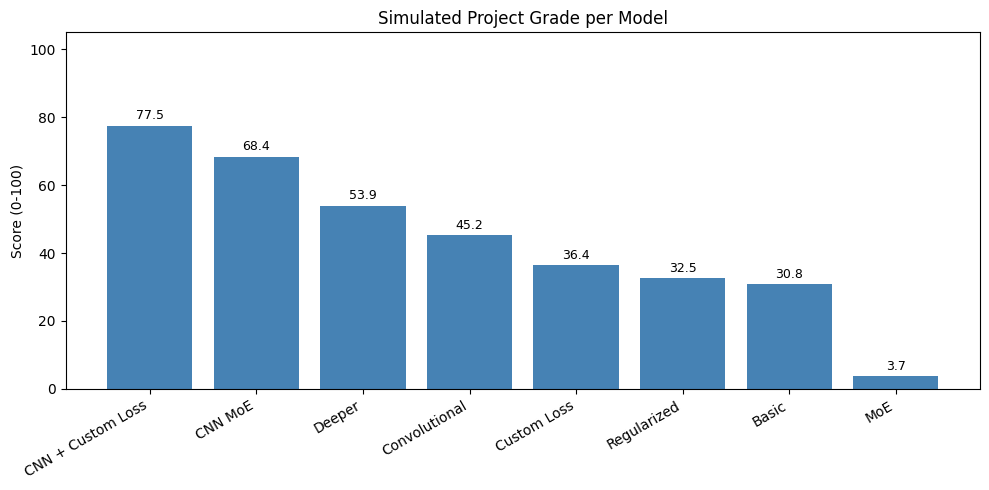

In [19]:
# === Evaluate ALL models using the project grading metric ===
# Cost per sample: sigma(y, y_hat) = (log2(y) - log2(y_hat))^2
# Predictions must be >= 1
# Grading: flipped sigmoid scored 0-100, parametrized by class median & quartile

import matplotlib.pyplot as plt

# ── helpers ──────────────────────────────────────────────────

def get_group_costs(y_pred_log, X_data, y_data):
    """Return dict mapping (k,m) -> avg cost for this model."""
    y_pred = np.exp(y_pred_log)
    y_actual = np.exp(y_data)
    y_pred = np.maximum(y_pred, 1.0)
    cost_per_sample = (np.log2(y_actual) - np.log2(y_pred)) ** 2
    group_costs = {}
    for k_val in [4, 5, 6]:
        for m_val in range(2, 10 - k_val):
            k_idx, m_idx = k_val - 4, m_val - 2
            mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
            if mask.sum() > 0:
                group_costs[(k_val, m_val)] = cost_per_sample[mask].mean()
    return group_costs

def grade_models(all_group_costs):
    """
    Simulate project grading as if each model were a different student.
    
    For each (k,m) group:
      θ = median cost across all 'students' (models)
      α = ln(3) / (θ - q25_cost)      where q25_cost = 25th percentile
      β = max{ (100/(e^{α(σ-θ)}+1) - 50) * 50/(100/(e^{-αθ}+1)-50) + 50, 0 }
    
    Final score = average β across all 9 groups.
    """
    model_names = list(all_group_costs.keys())
    groups = list(next(iter(all_group_costs.values())).keys())  # all (k,m) pairs
    
    # Per-group score for each model
    model_group_scores = {name: {} for name in model_names}
    
    for grp in groups:
        # Collect all models' costs for this group
        costs = np.array([all_group_costs[name][grp] for name in model_names])
        sorted_costs = np.sort(costs)
        M = len(sorted_costs)
        
        # θ = median cost, q25 = 25th-percentile cost
        theta = sorted_costs[int(np.ceil(M / 2)) - 1]
        q25 = sorted_costs[int(np.ceil(M / 4)) - 1]
        
        for name in model_names:
            sigma = all_group_costs[name][grp]
            if theta - q25 > 1e-12:
                alpha = np.log(3) / (theta - q25)
            else:
                # All models nearly identical → give full marks if cost ≤ theta
                alpha = 100.0  # steep sigmoid
            
            # Denominator normalization factor
            denom = 100.0 / (np.exp(-alpha * theta) + 1) - 50
            if abs(denom) < 1e-12:
                denom = 1e-12
            
            beta = max(
                (100.0 / (np.exp(alpha * (sigma - theta)) + 1) - 50) * 50.0 / denom + 50,
                0.0
            )
            model_group_scores[name][grp] = beta
    
    # Final score = average across groups
    final_scores = {}
    for name in model_names:
        final_scores[name] = np.mean(list(model_group_scores[name].values()))
    
    return model_group_scores, final_scores

# ── Collect predictions & per-group costs for every model ────

all_group_costs = {}

# Single-input models from the results dict
for name, (mdl, hist) in results.items():
    preds = mdl.predict(X_test, verbose=0).flatten()
    all_group_costs[name] = get_group_costs(preds, X_test, y_test)

# MoE (MLP experts)
if 'moe_models' in globals():
    moe_preds = predict_moe(moe_models, X_test)
    all_group_costs['MoE'] = get_group_costs(moe_preds, X_test, y_test)

# CNN MoE (if trained)
if 'cnn_moe_models' in globals():
    cnn_moe_preds = predict_cnn_moe(cnn_moe_models, X_test)
    all_group_costs['CNN MoE'] = get_group_costs(cnn_moe_preds, X_test, y_test)

# ── Grade all models ─────────────────────────────────────────

model_group_scores, final_scores = grade_models(all_group_costs)

# ── Detailed per-group table ─────────────────────────────────

groups = sorted(next(iter(all_group_costs.values())).keys())
model_names = list(all_group_costs.keys())

print(f"\n{'=' * 80}")
print(f"  PER-GROUP AVERAGE COST  (lower = better)")
print(f"{'=' * 80}")
header = f"{'Model':<22}" + "".join(f"  k={k},m={m}" for k, m in groups)
print(header)
print("-" * len(header))
for name in model_names:
    row = f"{name:<22}"
    for grp in groups:
        row += f"  {all_group_costs[name][grp]:>7.4f}"
    print(row)

print(f"\n{'=' * 80}")
print(f"  PER-GROUP SCORE (0-100, higher = better)")
print(f"{'=' * 80}")
header = f"{'Model':<22}" + "".join(f"  k={k},m={m}" for k, m in groups)
print(header)
print("-" * len(header))
for name in model_names:
    row = f"{name:<22}"
    for grp in groups:
        row += f"  {model_group_scores[name][grp]:>7.1f}"
    print(row)

# ── Final scores summary ─────────────────────────────────────

print(f"\n{'=' * 60}")
print(f"  FINAL MODEL SCORES (simulated grading, 0-100)")
print(f"{'=' * 60}")
print(f"{'Model':<22} {'Avg Cost':>10} {'Score':>8}")
print("-" * 42)
for name, score in sorted(final_scores.items(), key=lambda x: -x[1]):
    avg_cost = np.mean(list(all_group_costs[name].values()))
    print(f"{name:<22} {avg_cost:>10.6f} {score:>7.1f}")

best_name = max(final_scores, key=final_scores.get)
print(f"\n>>> Best model: {best_name}  (score = {final_scores[best_name]:.1f}/100)")

# ── Plot training curves for all models including MoE ────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single-input models
for name, (mdl, hist) in results.items():
    axes[0].plot(hist.history['loss'], label=f'{name} train')
    axes[0].plot(hist.history['val_loss'], '--', label=f'{name} val')
    axes[1].plot(hist.history['mae'], label=f'{name} train')
    axes[1].plot(hist.history['val_mae'], '--', label=f'{name} val')

# MoE: average loss/mae across the 9 experts per epoch.
# Early stopping means experts may have different history lengths —
# truncate to the shortest to keep arrays homogeneous before averaging.
def avg_moe_curves(histories):
    """Average training curves across all MoE experts, truncated to min length."""
    all_loss  = [h.history['loss']     for h in histories.values()]
    all_vloss = [h.history['val_loss'] for h in histories.values()]
    all_mae   = [h.history['mae']      for h in histories.values()]
    all_vmae  = [h.history['val_mae']  for h in histories.values()]
    min_len = min(len(x) for x in all_loss)
    all_loss  = [x[:min_len] for x in all_loss]
    all_vloss = [x[:min_len] for x in all_vloss]
    all_mae   = [x[:min_len] for x in all_mae]
    all_vmae  = [x[:min_len] for x in all_vmae]
    return (np.mean(all_loss, axis=0), np.mean(all_vloss, axis=0),
            np.mean(all_mae, axis=0), np.mean(all_vmae, axis=0))

loss, vloss, mae, vmae = avg_moe_curves(moe_histories)
axes[0].plot(loss, label='MoE train')
axes[0].plot(vloss, '--', label='MoE val')
axes[1].plot(mae, label='MoE train')
axes[1].plot(vmae, '--', label='MoE val')

if 'cnn_moe_histories' in globals():
    loss, vloss, mae, vmae = avg_moe_curves(cnn_moe_histories)
    axes[0].plot(loss, label='CNN MoE train')
    axes[0].plot(vloss, '--', label='CNN MoE val')
    axes[1].plot(mae, label='CNN MoE train')
    axes[1].plot(vmae, '--', label='CNN MoE val')

axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
axes[1].set_title('MAE'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

# ── Bar chart of final scores ────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
names_sorted = sorted(final_scores, key=final_scores.get, reverse=True)
scores_sorted = [final_scores[n] for n in names_sorted]
bars = ax2.bar(names_sorted, scores_sorted, color='steelblue')
ax2.set_ylabel('Score (0-100)')
ax2.set_title('Simulated Project Grade per Model')
ax2.set_ylim(0, 105)
for bar, s in zip(bars, scores_sorted):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{s:.1f}',
             ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 5 Choose an MOE based on the best models per group.

Hybrid MoE assignment:
  k=4, m=2 -> Deeper               (cost=0.2387)
  k=4, m=3 -> Deeper               (cost=0.2833)
  k=4, m=4 -> Deeper               (cost=0.6520)
  k=4, m=5 -> CNN + Custom Loss    (cost=2.2269)
  k=5, m=2 -> Deeper               (cost=0.4334)
  k=5, m=3 -> Deeper               (cost=0.6157)
  k=5, m=4 -> CNN + Custom Loss    (cost=2.4425)
  k=6, m=2 -> Deeper               (cost=0.5152)
  k=6, m=3 -> Convolutional        (cost=2.3107)


W0000 00:00:1773343589.537205    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.537366    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.537526    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.537589    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.537638    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.537678    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.537728    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.537837    5875 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.537974    5875 gp


  FINAL MODEL SCORES (with Hybrid MoE)
Model                    Avg Cost    Score
------------------------------------------
CNN + Custom Loss        1.072058    81.5
Hybrid MoE               1.079798    77.8
CNN MoE                  1.162306    69.5
Deeper                   1.138617    59.0
Convolutional            1.181995    46.3
Custom Loss              1.189034    38.3
Regularized              1.196103    35.7
Basic                    1.202278    34.4
MoE                      1.565485     3.8

>>> Best model: CNN + Custom Loss  (score = 81.5/100)


W0000 00:00:1773343589.834790    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.834922    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.834978    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.835021    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.835143    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.835213    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.835398    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.835630    5872 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773343589.835967    5872 gp

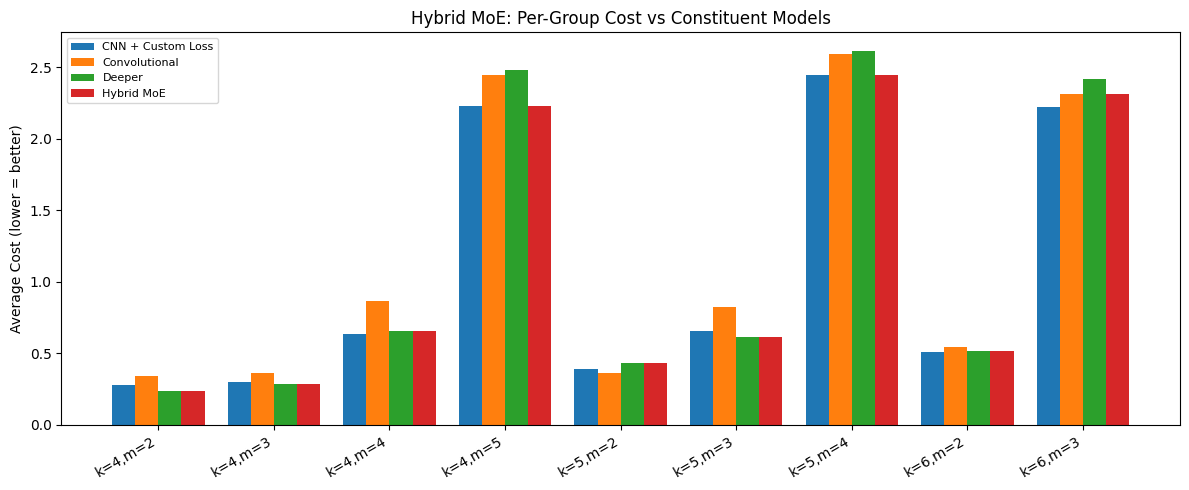

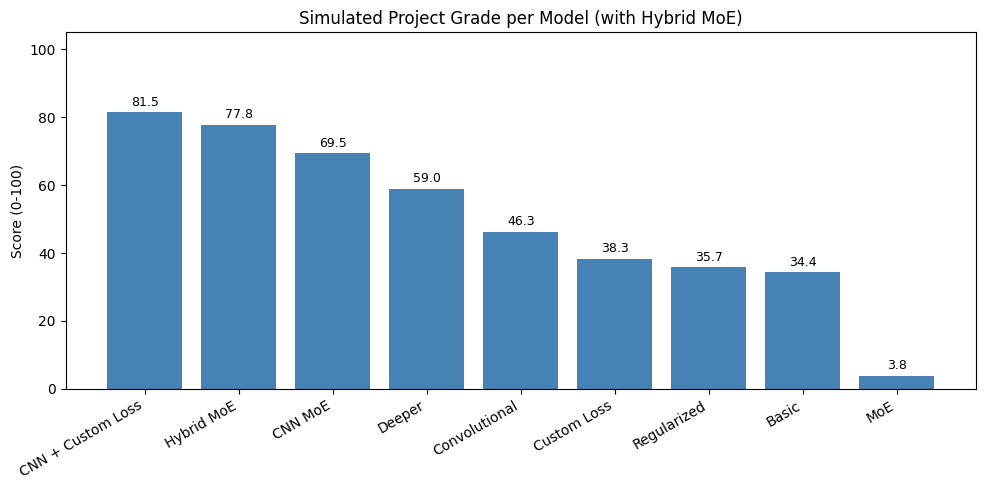

In [20]:

# ── Hybrid MoE: pick the best-performing model per (k, m) group ──

# Map each (k, m) to the model with lowest validation cost
best_model_map = {
    (4, 2): ('Deeper',          deeper_model),
    (4, 3): ('Deeper',          deeper_model),
    (4, 4): ('Deeper',          deeper_model),
    (4, 5): ('CNN + Custom Loss', cnn_custom_model),
    (5, 2): ('Deeper',          deeper_model),
    (5, 3): ('Deeper',          deeper_model),
    (5, 4): ('CNN + Custom Loss', cnn_custom_model),
    (6, 2): ('Deeper',          deeper_model),
    (6, 3): ('Convolutional',   conv_model),
}

print("Hybrid MoE assignment:")
for (k, m), (name, _) in sorted(best_model_map.items()):
    cost = all_group_costs[name][(k, m)]
    print(f"  k={k}, m={m} -> {name:<20s} (cost={cost:.4f})")

# ── Predict with the hybrid MoE ─────────────────────────────
def predict_hybrid_moe(best_model_map, X_data):
    predictions = np.zeros(len(X_data))
    for (k_val, m_val), (_, model) in best_model_map.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
        if mask.sum() > 0:
            predictions[mask] = model.predict(X_data[mask], verbose=0).flatten()
    return predictions

hybrid_preds = predict_hybrid_moe(best_model_map, X_test)
all_group_costs['Hybrid MoE'] = get_group_costs(hybrid_preds, X_test, y_test)

# ── Re-grade with the new hybrid model included ─────────────
model_group_scores, final_scores = grade_models(all_group_costs)

# Print final scores
print(f"\n{'=' * 60}")
print(f"  FINAL MODEL SCORES (with Hybrid MoE)")
print(f"{'=' * 60}")
print(f"{'Model':<22} {'Avg Cost':>10} {'Score':>8}")
print("-" * 42)
for name, score in sorted(final_scores.items(), key=lambda x: -x[1]):
    avg_cost = np.mean(list(all_group_costs[name].values()))
    print(f"{name:<22} {avg_cost:>10.6f} {score:>7.1f}")

best_name = max(final_scores, key=final_scores.get)
print(f"\n>>> Best model: {best_name}  (score = {final_scores[best_name]:.1f}/100)")

# ── Plot: Per-group cost comparison (Hybrid MoE vs constituents) ──

import matplotlib.pyplot as plt

groups = sorted(all_group_costs['Hybrid MoE'].keys())
group_labels = [f"k={k},m={m}" for k, m in groups]

# Identify the unique constituent models used by the hybrid
constituent_names = sorted(set(name for name, _ in best_model_map.values()))
plot_models = constituent_names + ['Hybrid MoE']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(groups))
width = 0.8 / len(plot_models)
for i, mname in enumerate(plot_models):
    costs = [all_group_costs[mname][grp] for grp in groups]
    bars = ax.bar(x + i * width, costs, width, label=mname)
ax.set_xticks(x + width * (len(plot_models) - 1) / 2)
ax.set_xticklabels(group_labels, rotation=30, ha='right')
ax.set_ylabel('Average Cost (lower = better)')
ax.set_title('Hybrid MoE: Per-Group Cost vs Constituent Models')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Bar chart of final scores (with Hybrid MoE) ──
fig2, ax2 = plt.subplots(figsize=(10, 5))
names_sorted = sorted(final_scores, key=final_scores.get, reverse=True)
scores_sorted = [final_scores[n] for n in names_sorted]
bars = ax2.bar(names_sorted, scores_sorted, color='steelblue')
ax2.set_ylabel('Score (0-100)')
ax2.set_title('Simulated Project Grade per Model (with Hybrid MoE)')
ax2.set_ylim(0, 105)
for bar, s in zip(bars, scores_sorted):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{s:.1f}',
             ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()



## 5 Retrain the Hybrid MOE model with the larger dataset and compare again

In [ ]:

# ── Load ALL available datasets ──────────────────────────────
# 1) Professor's original training data (~96K samples)
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-n_k_m_P', 'rb') as f:
    prof_data = pickle.load(f)
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-mHeights', 'rb') as f:
    prof_heights = pickle.load(f)

# 2) Random-generated data (100K samples, sections 1-4 of generate_data)
with open('/workspace/Homework/Project1/Generated_n_k_m_P', 'rb') as f:
    rand_data = pickle.load(f)
with open('/workspace/Homework/Project1/Generated_m-heights', 'rb') as f:
    rand_heights = pickle.load(f)

# 3) Search-generated data (10K diverse samples, section 5 of generate_data)
with open('/workspace/Homework/Project1/Search_Generated_n_k_m_P', 'rb') as f:
    search_data = pickle.load(f)
with open('/workspace/Homework/Project1/Search_Generated_m-heights', 'rb') as f:
    search_heights = pickle.load(f)

# Combine all sources
gen_data    = prof_data + rand_data + search_data
gen_heights = list(prof_heights) + list(rand_heights) + list(search_heights)

print(f"Combined dataset: {len(gen_data)} samples")
print(f"  Professor: {len(prof_data)}, Random: {len(rand_data)}, Search: {len(search_data)}")

# 70/20/10 split
gen_train_data, gen_temp_data, gen_train_heights, gen_temp_heights = train_test_split(
    gen_data, gen_heights, test_size=0.3, random_state=42
)
gen_val_data, gen_test_data, gen_val_heights, gen_test_heights = train_test_split(
    gen_temp_data, gen_temp_heights, test_size=1/3, random_state=42
)
print(f"Train: {len(gen_train_data)}, Val: {len(gen_val_data)}, Test: {len(gen_test_data)}")

# Preprocess
X_train_gen = preprocess_features(gen_train_data)
y_train_gen = preprocess_labels(gen_train_heights)
X_val_gen   = preprocess_features(gen_val_data)
y_val_gen   = preprocess_labels(gen_val_heights)
X_test_gen  = preprocess_features(gen_test_data)
y_test_gen  = preprocess_labels(gen_test_heights)

print(f"X_train_gen: {X_train_gen.shape}, y_train_gen: {y_train_gen.shape}")
print(f"X_val_gen:   {X_val_gen.shape},   y_val_gen:   {y_val_gen.shape}")
print(f"X_test_gen:  {X_test_gen.shape},   y_test_gen:  {y_test_gen.shape}")

# Build tf.data pipelines
BATCH_SIZE_GEN = 4096
ds_train_gen = (tf.data.Dataset.from_tensor_slices((X_train_gen, y_train_gen.astype('float32')))
                .cache().shuffle(len(X_train_gen), seed=42)
                .batch(BATCH_SIZE_GEN).prefetch(tf.data.AUTOTUNE))
ds_val_gen = (tf.data.Dataset.from_tensor_slices((X_val_gen, y_val_gen.astype('float32')))
              .cache().batch(BATCH_SIZE_GEN).prefetch(tf.data.AUTOTUNE))

# ── Two-stage training ───────────────────────────────────────
# Stage 1: pre-train on full combined dataset (broad exposure)
# Stage 2: fine-tune on professor's data only (specialize to grading distribution)

EPOCHS_STAGE1   = 500
EPOCHS_STAGE2   = 100
FINETUNE_LR     = 1e-5

stage1_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)
stage2_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

def finetune_on_professor(model, name):
    """Stage 2: lower the learning rate and fine-tune on professor's data only."""
    print(f"\n--- Stage 2: Fine-tuning {name} on professor's data (lr={FINETUNE_LR}) ---")
    keras.backend.set_value(model.optimizer.learning_rate, FINETUNE_LR)
    return model.fit(ds_train, validation_data=ds_val,
                     epochs=EPOCHS_STAGE2, verbose=1,
                     callbacks=[keras.callbacks.EarlyStopping(
                         monitor='val_loss', patience=20,
                         restore_best_weights=True, verbose=1)])

# 1) Deeper model (used for 6 groups)
print("\n" + "=" * 60)
print("Stage 1: Deeper Model on combined data")
print("=" * 60)
deeper_gen = create_deeper_model()
deeper_gen_hist = deeper_gen.fit(ds_train_gen, validation_data=ds_val_gen,
                                 epochs=EPOCHS_STAGE1, verbose=1, callbacks=[stage1_cb])
deeper_ft_hist = finetune_on_professor(deeper_gen, "Deeper")

# 2) CNN + Custom Loss model (used for k=4,m=5 and k=5,m=4)
print("\n" + "=" * 60)
print("Stage 1: CNN + Custom Loss Model on combined data")
print("=" * 60)
cnn_custom_gen = create_cnn_custom_loss_model()
cnn_custom_gen_hist = cnn_custom_gen.fit(ds_train_gen, validation_data=ds_val_gen,
                                          epochs=EPOCHS_STAGE1, verbose=1, callbacks=[stage1_cb])
cnn_ft_hist = finetune_on_professor(cnn_custom_gen, "CNN + Custom Loss")

# 3) Convolutional model (used for k=6,m=3)
print("\n" + "=" * 60)
print("Stage 1: Convolutional Model on combined data")
print("=" * 60)
conv_gen = create_convolutional_model()
conv_gen_hist = conv_gen.fit(ds_train_gen, validation_data=ds_val_gen,
                              epochs=EPOCHS_STAGE1, verbose=1, callbacks=[stage1_cb])
conv_ft_hist = finetune_on_professor(conv_gen, "Convolutional")

# ── Assemble the retrained Hybrid MoE ────────────────────────
best_model_map_gen = {
    (4, 2): ('Deeper',            deeper_gen),
    (4, 3): ('Deeper',            deeper_gen),
    (4, 4): ('Deeper',            deeper_gen),
    (4, 5): ('CNN + Custom Loss', cnn_custom_gen),
    (5, 2): ('Deeper',            deeper_gen),
    (5, 3): ('Deeper',            deeper_gen),
    (5, 4): ('CNN + Custom Loss', cnn_custom_gen),
    (6, 2): ('Deeper',            deeper_gen),
    (6, 3): ('Convolutional',     conv_gen),
}

# ── Evaluate on ORIGINAL test set for fair comparison ──
hybrid_gen_preds = predict_hybrid_moe(best_model_map_gen, X_test)
all_group_costs['Hybrid MoE (retrained)'] = get_group_costs(hybrid_gen_preds, X_test, y_test)

# Also evaluate on the generated validation set
hybrid_gen_preds_gen = predict_hybrid_moe(best_model_map_gen, X_test_gen)
all_group_costs_gen = {}
all_group_costs_gen['Hybrid MoE (retrained)'] = get_group_costs(hybrid_gen_preds_gen, X_test_gen, y_test_gen)

# ── Re-grade all models (including retrained hybrid) ─────────
model_group_scores, final_scores = grade_models(all_group_costs)

groups = sorted(next(iter(all_group_costs.values())).keys())
print(f"\n{'=' * 80}")
print(f"  PER-GROUP AVERAGE COST  (lower = better)")
print(f"{'=' * 80}")
header = f"{'Model':<28}" + "".join(f"  k={k},m={m}" for k, m in groups)
print(header)
print("-" * len(header))
for nm in sorted(all_group_costs.keys()):
    row = f"{nm:<28}"
    for grp in groups:
        row += f"  {all_group_costs[nm][grp]:>7.4f}"
    print(row)

print(f"\n{'=' * 60}")
print(f"  FINAL MODEL SCORES (all models, 0-100)")
print(f"{'=' * 60}")
print(f"{'Model':<28} {'Avg Cost':>10} {'Score':>8}")
print("-" * 48)
for nm, sc in sorted(final_scores.items(), key=lambda x: -x[1]):
    avg_c = np.mean(list(all_group_costs[nm].values()))
    print(f"{nm:<28} {avg_c:>10.6f} {sc:>7.1f}")

best_name = max(final_scores, key=final_scores.get)
print(f"\n>>> Best model: {best_name}  (score = {final_scores[best_name]:.1f}/100)")

# ── Plot: Training curves (Stage 1 + Stage 2) ───────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Stage 1 curves
retrained_hists = {
    'Deeper': deeper_gen_hist,
    'CNN+Custom': cnn_custom_gen_hist,
    'Conv': conv_gen_hist,
}
for label, hist in retrained_hists.items():
    axes[0, 0].plot(hist.history['loss'], label=f'{label} train')
    axes[0, 0].plot(hist.history['val_loss'], '--', label=f'{label} val')
    axes[0, 1].plot(hist.history['mae'], label=f'{label} train')
    axes[0, 1].plot(hist.history['val_mae'], '--', label=f'{label} val')
axes[0, 0].set_title('Stage 1 (Combined Data) - Loss')
axes[0, 0].legend(fontsize=8)
axes[0, 1].set_title('Stage 1 (Combined Data) - MAE')
axes[0, 1].legend(fontsize=8)

# Stage 2 curves
ft_hists = {
    'Deeper': deeper_ft_hist,
    'CNN+Custom': cnn_ft_hist,
    'Conv': conv_ft_hist,
}
for label, hist in ft_hists.items():
    axes[1, 0].plot(hist.history['loss'], label=f'{label} train')
    axes[1, 0].plot(hist.history['val_loss'], '--', label=f'{label} val')
    axes[1, 1].plot(hist.history['mae'], label=f'{label} train')
    axes[1, 1].plot(hist.history['val_mae'], '--', label=f'{label} val')
axes[1, 0].set_title("Stage 2 (Fine-tune on Professor's Data) - Loss")
axes[1, 0].legend(fontsize=8)
axes[1, 1].set_title("Stage 2 (Fine-tune on Professor's Data) - MAE")
axes[1, 1].legend(fontsize=8)

for ax in axes.flat:
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# ── Plot: Per-group cost - Original Hybrid MoE vs Retrained ──

group_labels = [f"k={k},m={m}" for k, m in groups]
fig2, ax2 = plt.subplots(figsize=(12, 5))
x = np.arange(len(groups))
width = 0.35
orig_costs = [all_group_costs['Hybrid MoE'][grp] for grp in groups]
retrained_costs = [all_group_costs['Hybrid MoE (retrained)'][grp] for grp in groups]
ax2.bar(x - width/2, orig_costs, width, label='Hybrid MoE (original)')
ax2.bar(x + width/2, retrained_costs, width, label='Hybrid MoE (retrained)')
ax2.set_xticks(x)
ax2.set_xticklabels(group_labels, rotation=30, ha='right')
ax2.set_ylabel('Average Cost (lower = better)')
ax2.set_title('Per-Group Cost: Original vs Retrained Hybrid MoE')
ax2.legend()
plt.tight_layout()
plt.show()

# ── Bar chart of final scores (all models including retrained) ──

fig3, ax3 = plt.subplots(figsize=(12, 5))
names_sorted = sorted(final_scores, key=final_scores.get, reverse=True)
scores_sorted = [final_scores[n] for n in names_sorted]
bars = ax3.bar(names_sorted, scores_sorted, color='steelblue')
ax3.set_ylabel('Score (0-100)')
ax3.set_title('Simulated Project Grade per Model (All Models)')
ax3.set_ylim(0, 105)
for bar, s in zip(bars, scores_sorted):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{s:.1f}',
             ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Quick diagnostic: print final scores and the generated dataset sizes
print("=== FINAL SCORES (all models) ===")
for nm, sc in sorted(final_scores.items(), key=lambda x: -x[1]):
    avg_c = np.mean(list(all_group_costs[nm].values()))
    print(f"  {nm:<28} cost={avg_c:.6f}  score={sc:.1f}")

print(f"\nOriginal dataset: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
print(f"Generated dataset: train={len(X_train_gen)}, val={len(X_val_gen)}, test={len(X_test_gen)}")

# Check: how many epochs did each retrained model actually run?
print(f"\nRetrained Deeper: {len(deeper_gen_hist.history['loss'])} epochs")
print(f"Retrained CNN+Custom: {len(cnn_custom_gen_hist.history['loss'])} epochs")
print(f"Retrained Conv: {len(conv_gen_hist.history['loss'])} epochs")

# Final train/val loss for retrained models
print(f"\nRetrained Deeper     - train_loss: {deeper_gen_hist.history['loss'][-1]:.4f}, val_loss: {deeper_gen_hist.history['val_loss'][-1]:.4f}")
print(f"Retrained CNN+Custom - train_loss: {cnn_custom_gen_hist.history['loss'][-1]:.4f}, val_loss: {cnn_custom_gen_hist.history['val_loss'][-1]:.4f}")
print(f"Retrained Conv       - train_loss: {conv_gen_hist.history['loss'][-1]:.4f}, val_loss: {conv_gen_hist.history['val_loss'][-1]:.4f}")

# Compare: retrained hybrid on ORIGINAL test vs generated val
print(f"\nHybrid MoE (retrained) on ORIGINAL test:")
for grp in sorted(all_group_costs['Hybrid MoE (retrained)'].keys()):
    print(f"  {grp}: {all_group_costs['Hybrid MoE (retrained)'][grp]:.6f}")

print(f"\nHybrid MoE (retrained) on GENERATED test:")
for grp in sorted(all_group_costs_gen['Hybrid MoE (retrained)'].keys()):
    print(f"  {grp}: {all_group_costs_gen['Hybrid MoE (retrained)'][grp]:.6f}")

# Compare original Hybrid MoE vs retrained
if 'Hybrid MoE' in all_group_costs:
    print(f"\nOriginal Hybrid MoE on ORIGINAL test:")
    for grp in sorted(all_group_costs['Hybrid MoE'].keys()):
        print(f"  {grp}: {all_group_costs['Hybrid MoE'][grp]:.6f}")


=== FINAL SCORES (all models) ===
  CNN + Custom Loss            cost=1.072058  score=81.5
  Hybrid MoE                   cost=1.079798  score=77.8
  CNN MoE                      cost=1.162306  score=69.5
  Deeper                       cost=1.138617  score=59.0
  Convolutional                cost=1.181995  score=46.3
  Custom Loss                  cost=1.189034  score=38.3
  Regularized                  cost=1.196103  score=35.7
  Basic                        cost=1.202278  score=34.4
  MoE                          cost=1.565485  score=3.8
  Hybrid MoE (retrained)       cost=4.137389  score=0.0

Original dataset: train=67566, val=19305, test=9653
Generated dataset: train=70000, val=20000, test=10000

Retrained Deeper: 71 epochs
Retrained CNN+Custom: 100 epochs
Retrained Conv: 377 epochs

Retrained Deeper     - train_loss: 0.4102, val_loss: 0.7788
Retrained CNN+Custom - train_loss: 1.1242, val_loss: 1.5044
Retrained Conv       - train_loss: 0.5526, val_loss: 0.5809

Hybrid MoE (retraine